<a href="https://colab.research.google.com/github/Jsanch1020/is201/blob/main/Ex15-TestingCAPM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Investments: Theory and Data Analysis**, Bates, Boyer, and Fletcher

# Example Chapter 15: Testing the CAPM
In this notebook we download return data from Ken French's website and estimate the CAPM alphas for each porfolio along with the 95% confidence intervals.   

### Imports and Setup

I certify that I have followed all quiz rules and procedures and that this work is my own.

In [5]:
%pip install -q simple-finance
import simple_finance as sf
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

### Choose Strategy and Estimate Alpha
In the block of code below we use the function `get_ff_strategies` which downloads the historical returns on various trading strategies from Ken French's website, along with the return on the market value-weighted portfolio and the return on short-term t-bills. These strategies are based on decile-sorts. See `Ex07-Ken_French.ipynb` for more details.    


In [6]:
dat = sf.get_ff_strategies(stype='momentum', details=True)

dat_55_75 = dat[(dat.index >= '1955-01-01') & (dat.index < '1975-01-01')]
dat_75_95 = dat[(dat.index >= '1975-01-01') & (dat.index < '1995-01-01')]
dat_95_25 = dat[(dat.index >= '1995-01-01') & (dat.index < '2026-01-01')]

----------------
Momentum Strategy
----------------
Basic Strategy: stocks are sorted into deciles based on their prior 12-month returns, excluding the most recent month.

Construction: The portfolios are constructed monthly using NYSE prior (2-12) return decile breakpoints.

Stocks: The portfolios constructed each month include NYSE, AMEX, and NASDAQ stocks with prior return data.
To be included in a portfolio for month t (formed at the end of month t-1), a stock must have a price for the
end of month t-13 and a good return for t-2. In addition, any missing returns from t-12 to t-3 must be -99.0,
CRSP's code for a missing price. Each included stock also must have ME for the end of month t-1.

Min Date: 1927-01, Max Date: 2026-01


In [7]:
def estimate_alphas(dat):
    intercepts = []
    conf_intervals = []

    for column in [f"Dec {i}" for i in range(1, 11)]:
        y = dat[column] - dat['rf']
        X = dat['mkt-rf']
        X = sm.add_constant(X)

        model = sm.OLS(y, X).fit()

        intercept = model.params['const'] * 12
        ci_lower, ci_upper = model.conf_int().iloc[0] * 12

        intercepts.append(intercept)
        conf_intervals.append([ci_lower, ci_upper])

    results_df = pd.DataFrame({
        "Decile": [f"Dec {i}" for i in range(1, 11)],
        "Alpha": intercepts,
        "CI_Lower": [ci[0] for ci in conf_intervals],
        "CI_Upper": [ci[1] for ci in conf_intervals]
    })

    return results_df

In [2]:
# Choose the strategy
# Import all available monthly data
#dat=sf.get_ff_strategies(stype='momentum',details=True)
#dat_55_75 = dat[(dat.index >= '1955-01-01') & (dat.index < '1975-01-01')]
#dat_75_95 = dat[(dat.index >= '1975-01-01') & (dat.index < '1995-01-01')]
#dat_95_25 = dat[(dat.index >= '1995-01-01') & (dat.index < '2025-01-01')]
# Initialize lists to store intercepts and confidence intervals
#def estimate_alphas(dat):
  #  intercepts = []
   # conf_intervals = []

# Loop through each column corresponding to Dec 1 - Dec 10
   # for column in [f"Dec {i}" for i in range(1, 11)]:
      #  y = dat[column]-dat['rf']  # Dependent variable (Decile return)
      #  X = dat['mkt-rf']  # Independent variable (Market excess return)
      #  X = sm.add_constant(X)    # Add constant to X for intercept

    # Fit regression model
      #  model = sm.OLS(y, X).fit()

    # Get the intercept and 95% confidence intervals
      #  intercept = model.params['const'] * 12  # Multiply intercept by 12 to annualize
       # ci_lower, ci_upper = model.conf_int().iloc[0] * 12  # Multiply confidence intervals by 12 to annualize

    # Get the intercept and 95% confidence intervals
      #  intercepts.append(intercept)  # Append intercept to list
      #  conf_intervals.append([ci_lower, ci_upper])  # Append 95% CI for the intercept

# Convert results to DataFrame for easier manipulation
    #results_df = pd.DataFrame({
     #   "Decile": [f"Dec {i}" for i in range(1, 11)],
      #  "Intercept": intercepts,
      #  "CI_Lower": [ci[0] for ci in conf_intervals],
      #  "CI_Upper": [ci[1] for ci in conf_intervals]
#})


----------------
Momentum Strategy
----------------
Basic Strategy: stocks are sorted into deciles based on their prior 12-month returns, excluding the most recent month.

Construction: The portfolios are constructed monthly using NYSE prior (2-12) return decile breakpoints.

Stocks: The portfolios constructed each month include NYSE, AMEX, and NASDAQ stocks with prior return data.
To be included in a portfolio for month t (formed at the end of month t-1), a stock must have a price for the
end of month t-13 and a good return for t-2. In addition, any missing returns from t-12 to t-3 must be -99.0,
CRSP's code for a missing price. Each included stock also must have ME for the end of month t-1.

Min Date: 1927-01, Max Date: 2026-01


In [8]:
results_55_75 = estimate_alphas(dat_55_75)
results_75_95 = estimate_alphas(dat_75_95)
results_95_25 = estimate_alphas(dat_95_25)


In [9]:
print("1955-1975")
print(results_55_75)

print("\n1975-1995")
print(results_75_95)

print("\n1995-2025")
print(results_95_25)

1955-1975
   Decile     Alpha  CI_Lower  CI_Upper
0   Dec 1 -0.108920 -0.159399 -0.058441
1   Dec 2 -0.070060 -0.107942 -0.032177
2   Dec 3 -0.026603 -0.061489  0.008284
3   Dec 4 -0.029423 -0.057260 -0.001586
4   Dec 5  0.004975 -0.017668  0.027617
5   Dec 6 -0.000316 -0.022647  0.022014
6   Dec 7  0.002928 -0.017734  0.023589
7   Dec 8  0.014962 -0.009597  0.039521
8   Dec 9  0.037508  0.012091  0.062926
9  Dec 10  0.099945  0.055855  0.144034

1975-1995
   Decile     Alpha  CI_Lower  CI_Upper
0   Dec 1 -0.114798 -0.168811 -0.060786
1   Dec 2 -0.016266 -0.059469  0.026936
2   Dec 3 -0.005152 -0.037719  0.027415
3   Dec 4 -0.002372 -0.025809  0.021064
4   Dec 5 -0.020863 -0.041215 -0.000510
5   Dec 6  0.000373 -0.018221  0.018967
6   Dec 7 -0.000002 -0.019765  0.019761
7   Dec 8  0.021673 -0.001970  0.045316
8   Dec 9  0.036089  0.005992  0.066186
9  Dec 10  0.053613  0.013112  0.094114

1995-2025
   Decile     Alpha  CI_Lower  CI_Upper
0   Dec 1 -0.109923 -0.186425 -0.033420
1   Dec 

### Plot the Alphas with 95% Confidence Intervals

In [10]:
def plot_alphas(results_df, title):
    plt.figure(figsize=(10, 6))
    plt.errorbar(
        results_df["Decile"],
        results_df["Alpha"],
        yerr=[
            results_df["Alpha"] - results_df["CI_Lower"],
            results_df["CI_Upper"] - results_df["Alpha"]
        ],
        fmt='o',
        capsize=5,
        capthick=2
    )

    plt.axhline(0, linestyle='--', linewidth=2)
    plt.xlabel("Decile", fontsize=14)
    plt.ylabel("Alpha", fontsize=14)
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
    plt.show()

In [4]:
# Plot the intercepts with confidence intervals
#plt.figure(figsize=(10, 6))
#plt.errorbar(results_df["Decile"], results_df["Intercept"],
      #       yerr=[results_df["Intercept"] - results_df["CI_Lower"],
       #            results_df["CI_Upper"] - results_df["Intercept"]],
       #      fmt='o', capsize=5, capthick=2, label="Intercept ± 95% CI", color='b')

# Labels and title
#plt.xlabel("Decile",fontsize=16)
#plt.ylabel("Intercept",fontsize=16)
#plt.title("Regression Intercepts with 95% Confidence Intervals")
#plt.xticks(rotation=45)  # Rotate x-axis labels for readability
#plt.axhline(0, color='black', linestyle='--', linewidth=2)  # Reference line at 0
#plt.legend()
# Format y-axis as percentages
#plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))

# Show the plot
#plt.show()

NameError: name 'results_df' is not defined

<Figure size 1000x600 with 0 Axes>

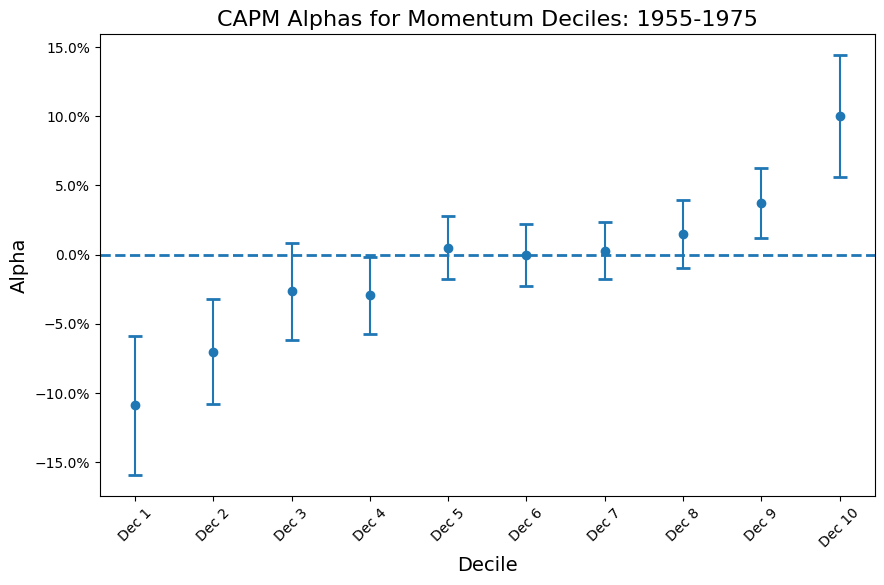

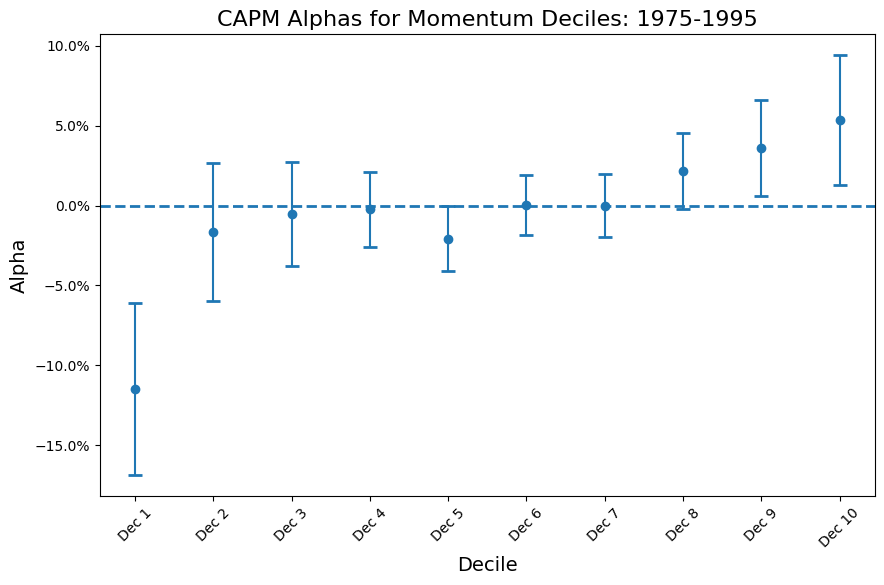

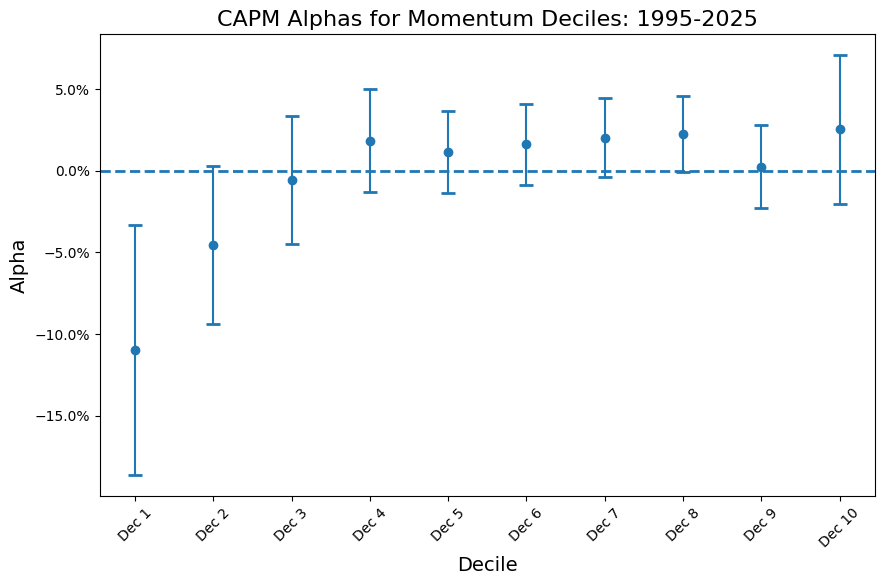

In [11]:
plot_alphas(results_55_75, "CAPM Alphas for Momentum Deciles: 1955-1975")
plot_alphas(results_75_95, "CAPM Alphas for Momentum Deciles: 1975-1995")
plot_alphas(results_95_25, "CAPM Alphas for Momentum Deciles: 1995-2025")